# Recinos Vectorize and Cluster

In [1]:
import pandas as pd
import numpy as np
import plotly_express as px

# Get data

In [2]:
OHCO = "parte capit sent token".split()

In [3]:
TOKEN = pd.read_csv('recinos-TOKEN.csv').set_index(OHCO)
VOCAB = pd.read_csv('recinos-VOCAB.csv').set_index('term_str')
DOC = pd.read_csv("recinos-CHAP.csv").set_index(OHCO[:2])
TFIDF = pd.read_csv("recinos-TFIDF.csv").set_index(OHCO[:2])

In [4]:
WORDEMB = pd.read_csv("recinos-VOCAB_VEC.csv").set_index('term_str')
WORDEMB.columns = [f"f_{str(col).zfill(3)}" for col in WORDEMB.columns]
f_cols = WORDEMB.columns.to_list()
WORDEMB = WORDEMB.join(VOCAB.stop)
DVM = TOKEN.join(WORDEMB, on='term_str', how='inner')[f_cols]\
    .groupby(['parte','capit']).agg('mean')

# Vectorize

In [5]:
DTM = pd.read_pickle("recinos-DTM.pickle")

In [6]:
DTM.head()

term_str     trituradas  blos  mientos  quedar  derribarlas  encendido  \
parte capit                                                              
0     1               0     0        0       0            0          0   
1     1               0     0        0       0            0          0   
      2               1     0        0       0            0          0   
      3               0     0        0       0            0          0   
      4               0     0        0       0            0          0   

term_str     inmovilidad  quedaba  enterraron  honores  ...  reverencias  \
parte capit                                             ...                
0     1                0        0           0        0  ...            0   
1     1                1        0           0        0  ...            0   
      2                1        0           0        0  ...            0   
      3                0        0           0        0  ...            0   
      4                0        0           0        0  ...            0   

term_str     sabia  murieras  tomemos  espantaban  ido  dirigiendo  inquietud  \
parte capit                                                                     
0     1          0         0        0           0    0           0          0   
1     1          0         0        0           0    0           0          0   
      2          0         0        0           0    0           0          0   
      3          0         0        0           0    0           0          0   
      4          0         0        0           0    0           0          0   

term_str     frutos  convertido  
parte capit                      
0     1           0           0  
1     1           0           0  
      2           0           0  
      3           0           0  
      4           0           0  

[5 rows x 3692 columns]

# Create PCA

In [7]:
from sklearn.decomposition import PCA

In [8]:
pca_engine = PCA(n_components=10)

In [9]:
PCA = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)

In [10]:
# PCA

# Cluster

In [11]:
import sys
sys.path.append("../../local_lib/")

In [12]:
from hac2 import HAC

In [13]:
M = TFIDF #[VOCAB.loc[VOCAB.stop == False].index]
# M = PCA

In [14]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

In [15]:
fig1 = HAC(M)
fig1.linkage_method = linkage
fig1.dist_metric = metric

In [16]:
fig1.color_thresh = 1.6
# fig1.color_thresh = .6
# fig1.color_thresh = 2.75

In [17]:
# fig1.orientation = 'top'

<Figure size 640x480 with 0 Axes>

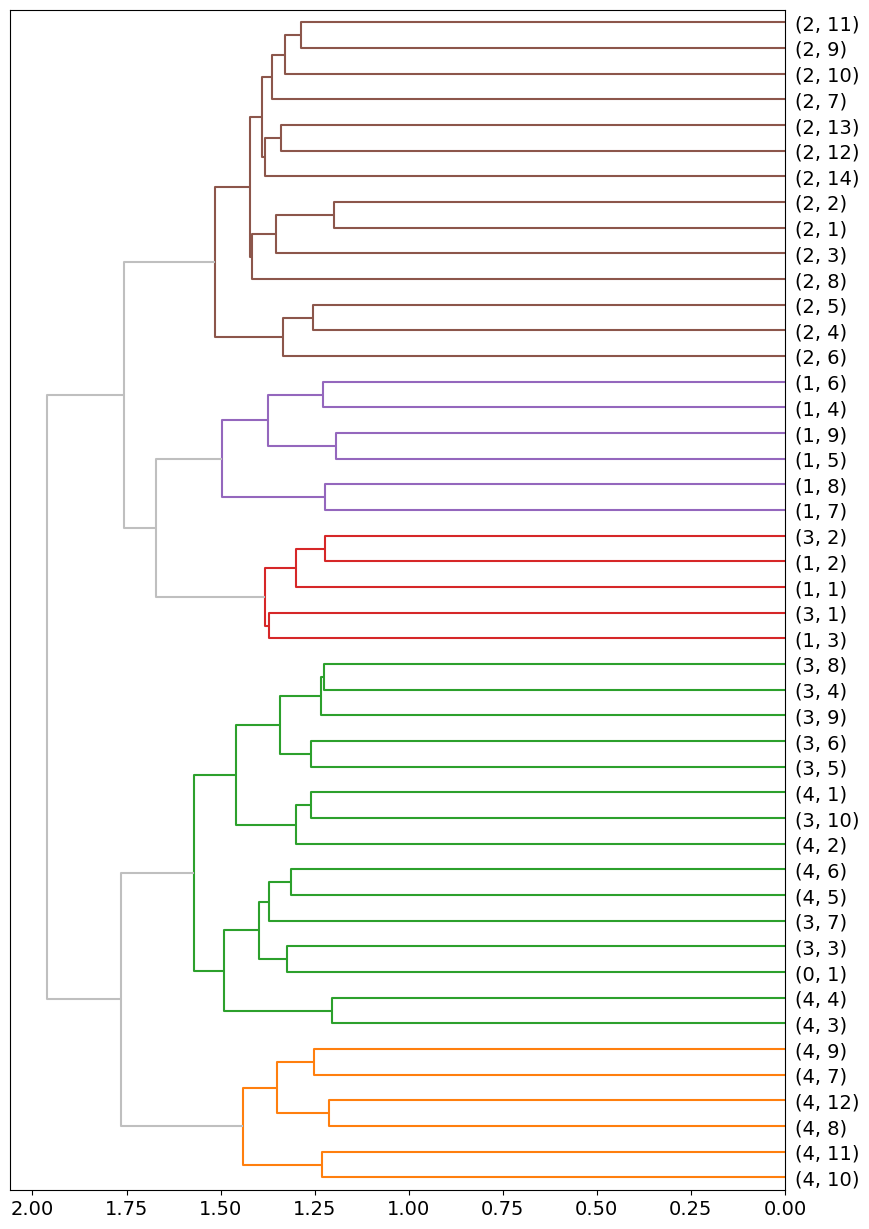

In [18]:
fig1.plot()

In [19]:
fig1.get_cluster_labels()
DOC['label'] = fig1.CLUSTER_LABELS
DOC.label = DOC.label.astype(str)

In [20]:
DOC.head()

doc_str  n_chars  \
parte capit                                                               
0     1      Este es el principio de las antiguas historias...     1861   
1     1      Esta es la relación de cómo todo estaba en sus...     3561   
      2      Luego hicieron a los animales pequeños del mon...     7952   
      3      En seguida fueron aniquilados, destruidos y de...     3712   
      4      Había entonces muy poca claridad sobre la faz ...     1659   

             n_words label  
parte capit                 
0     1          343     5  
1     1          608     2  
      2         1329     2  
      3          638     2  
      4          304     3

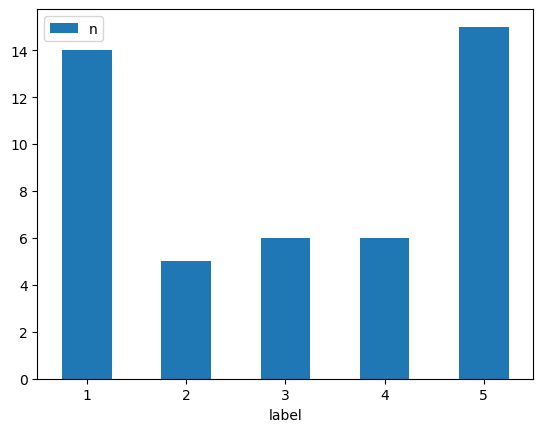

In [21]:
LABEL = DOC.label.value_counts().to_frame('n')
LABEL.sort_index().plot.bar(rot=0);

In [22]:
LABEL['color'] = pd.Series({
    '1': 'lightgray',
    '2': 'pink',
    '3': 'lightblue',
    '4': 'lightgreen',
    '5': 'lightyellow',
    '6': 'orange',
    '7': 'purple',
    '': 'white'
})

In [23]:
# LABEL

In [24]:
DOC.label.unstack(fill_value='')\
    .style.applymap(lambda x: 'background:' + LABEL.loc[x, 'color'] if x != '' else 'background:white')

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14
parte,,,,,,,,,,,,,,
0,5,,,,,,,,,,,,,
1,2,2,2,3,3,3,3,3,3,,,,,
2,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,2,2,5,5,5,5,5,5,5,5,,,,
4,5,5,5,5,5,5,4,4,4,4,4,4,,


# Gloss LABEL

In [25]:
LABEL_TFIDF = TFIDF.join(DOC.label).groupby('label').mean()
LABEL['top_words'] = LABEL_TFIDF.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(20).index.to_list()), axis=1)

In [26]:
for row in LABEL.iterrows():
    print(row[0], row[1]['top_words'])

5 tohil, tribus, balamacab, balamquitze, mahucutah, hacavitz, dios, oriente, avilix, iquibalam, sol, sacerdotes, aurora, fuego, mujeres, sacrificadores, ciudad, tulan, pueblos, nombre
1 xibalba, pelota, abuela, hunbatz, hunahpu, mensajeros, hunchouen, senores, huncame, arbol, ixbalanque, hunhunahpu, flores, casa, cabeza, picado, vucubcame, muchachos, juego, canas
3 vucubcaquix, zipacna, cabracan, hoyo, muchachos, cangrejo, luna, brazo, sol, decia, hunahpu, tierra, ixbalanque, dientes, fondo, riquezas, pajaros, claridad, montanas, cerbatana
4 senores, rey, generacion, reyes, casas, izmachi, quiche, cotuha, quicab, ahpop, ciudad, pueblos, ciudades, casa, familias, galel, convertia, reino, nihaib, ayunaban
2 formador, creador, creacion, progenitores, hombre, mazorcas, cielo, carne, tepeu, tierra, gucumatz, perros, criaturas, formacion, faz, maiz, tzite, alimentos, paxil, hablaron


In [27]:
LABEL['gloss'] = LABEL.top_words.str.split(',').str[0]

In [28]:
LABEL

,n,color,top_words,gloss
label,,,,
5,15,lightyellow,"tohil, tribus, balamacab, balamquitze, mahucut...",tohil
1,14,lightgray,"xibalba, pelota, abuela, hunbatz, hunahpu, men...",xibalba
3,6,lightblue,"vucubcaquix, zipacna, cabracan, hoyo, muchacho...",vucubcaquix
4,6,lightgreen,"senores, rey, generacion, reyes, casas, izmach...",senores
2,5,pink,"formador, creador, creacion, progenitores, hom...",formador


# Inspect

In [29]:
def show_chap(parte, capit):
    print(DOC.loc[(parte,capit)].doc_str)

In [30]:
# show_chap(1,3)

# Save

In [31]:
DOC[['label']].to_csv("recinos-CHAP-labels.csv", index=True)

In [32]:
tables = [
    (LABEL, 'LABEL'), 
    (DOC, 'DOC')
]

In [33]:
for df in tables:
    df[0].to_csv(f"recinos-{df[1]}.csv", index=True)